[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EQuS/jaxquantum/blob/main/docs/documentation/tutorials/cuquantum.ipynb)

In [1]:
# !pip install git+https://github.com/EQuS/jaxquantum.git  # Uncomment when running in Colab.
# !pip install nvidia-cuquantum-python                     # Required (GPU only).

# cuQuantum Backend

*This is an executable IPython Notebook tutorial.*

jaxquantum exposes a `"cuquantum"` storage backend that wraps `cuquantum.densitymat.jax.OperatorTerm`. Operators are stored as **mode-structured** terms rather than dense $d^N \times d^N$ matrices, and the solver path uses `cuquantum.densitymat.jax.operator_action` so the matrix-vector products that drive `mesolve` / `sesolve` run entirely on GPU.

**When to use it**

- Many-mode systems where the explicit $d^N \times d^N$ Hamiltonian doesn't fit on the GPU.
- Lindblad simulations where each step's matrix-vector product would otherwise materialise huge Kronecker products.

**Requirements**

- `pip install nvidia-cuquantum-python` (and a CUDA-capable GPU).
- `jax` with x64 enabled — jaxquantum sets this automatically on import.

This tutorial covers:

1. **Availability & registration** — how the optional dependency is wired in.
2. **Single-site primitives** — `destroy`, `create`, `num`, `sigmax`, …
3. **`Qarray.from_impl` and `to_backend`** — direct wrapping of pre-built impls and converting between backends.
4. **Composite operators** — `displace`, `squeeze`, `qubit_rotation` round-tripping back to cuquantum after `expm` densifies.
5. **Kets and the dense fallback** — backends that can't represent column vectors fall back gracefully.
6. **Default backend via `SETTINGS`** — flip the global default once.
7. **Multi-mode example** — a 4-site Bose-Hubbard chain assembled with `tensor` and run through `mesolve`.

## 1. Availability check

`cuquantum.densitymat.jax` is an *optional* dependency. `jaxquantum/core/__init__.py` wraps the backend's import in a `try / except ImportError`, so on machines without cuquantum the rest of jaxquantum still loads — only the cuquantum backend is unavailable.

When cuquantum loads successfully, `CuquantumImpl` self-registers with the central `QarrayImplType` registry. From there, every operator and `Qarray.create` call can dispatch to it by enum member or string.

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jaxquantum as jqt

# This import only succeeds on a host with cuquantum installed.
from cuquantum.densitymat.jax import OperatorTerm  # noqa: F401

print("registered impl class:", jqt.QarrayImplType.CUQUANTUM.get_impl_class())

# `mesolve` on a cuquantum-backed Hamiltonian uses ``operator_action``, which
# requires a CUDA device with a working FFI registration.  Operator
# construction, arithmetic, ``to_dense``, ``from_impl``, ``to_backend``, etc.
# all work without a GPU; we use this flag below to skip the GPU-only solver
# / timing cells on host-only boxes (or boxes where jax sees a CUDA device
# but the cuquantum FFI handler isn't actually wired up).
def _cuquantum_mesolve_works():
    try:
        H = jqt.sigmax(implementation="cuquantum")
        rho0 = jqt.basis(2, 0).to_dm()
        out = jqt.mesolve(H, rho0, jnp.array([0.0, 0.01]),
                          c_ops=[],
                          solver_options=jqt.SolverOptions.create(progress_meter=False))
        out.data.block_until_ready()
        return True
    except Exception:
        return False

HAS_CUDA = _cuquantum_mesolve_works()
print("cuquantum mesolve available:", HAS_CUDA)

/home/shanj/miniconda3/envs/cqt/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


registered impl class: <class 'jaxquantum.core.cuquantum_impl.CuquantumImpl'>
cuquantum mesolve available: True


## 2. Build single-site operators directly

Every primitive (`destroy`, `create`, `num`, `identity`, the Pauli helpers, `hadamard`) accepts `implementation="cuquantum"` and returns a one-mode `Qarray[CuquantumImpl]`.

Internally `operators.py` looks up the impl class via the registry and calls a smart class-method on it (`CuquantumImpl.single_site`, `CuquantumImpl.identity_term`, `SparseDiaImpl.from_diags`, …). This avoids the wasted `impl → raw data → impl` round-trip that an unstructured `Qarray.create` path would do, and lets `operators.py` stay free of any backend-specific imports.

In [3]:
d = 4
a  = jqt.destroy(d, implementation="cuquantum")
ad = jqt.create(d,  implementation="cuquantum")
n  = jqt.num(d,     implementation="cuquantum")
I  = jqt.identity(d, implementation="cuquantum")

print("a.impl_type:", a.impl_type)
print("a.shape:    ", a.shape)
print("a.dims:     ", a.dims)

# to_dense() round-trips for sanity checks. Don't use it in the hot loop —
# it materialises the full matrix and defeats the backend's purpose.
print("\nmatches dense backend:",
      jnp.allclose(a.to_dense().data, jqt.destroy(d).data))

a.impl_type: QarrayImplType.CUQUANTUM
a.shape:     (4, 4)
a.dims:      ((4,), (4,))

matches dense backend: True


## 3. `Qarray.from_impl` and `Qarray.to_backend`

Two factory / conversion methods make it easy to move data between backends:

- **`Qarray.from_impl(impl, dims=None, bdims=None)`** wraps a pre-built `QarrayImpl` (e.g. a `CuquantumImpl` returned by `CuquantumImpl.single_site`) into a `Qarray` *without* the data normalisation pass that `Qarray.create` does. This is what powers the smart constructors used internally by `operators.py`.
- **`Qarray.to_backend(implementation)`** converts an existing `Qarray` to a different backend. It tries the direct method on the source impl (`to_dense`, `to_sparse_bcoo`, `to_sparse_dia`) when one exists, and otherwise routes through dense — that is the path used to land on cuquantum from any other backend, since no source impl exposes a `to_cuquantum` method.

In [4]:
# Build directly from an impl instance — no dense intermediate.
from jaxquantum.core.cuquantum_impl import CuquantumImpl

impl = CuquantumImpl.single_site(jnp.diag(jnp.sqrt(jnp.arange(1, d, dtype=jnp.complex128)), k=1), d)
a_via_impl = jqt.Qarray.from_impl(impl)
print("a_via_impl.impl_type:", a_via_impl.impl_type)
print("matches jqt.destroy(d, ...):",
      jnp.allclose(a_via_impl.to_dense().data, a.to_dense().data))

a_via_impl.impl_type: QarrayImplType.CUQUANTUM
matches jqt.destroy(d, ...): True


In [5]:
# Cross-backend conversion via to_backend.
a_dense    = jqt.destroy(d)                                 # dense
a_dia      = jqt.destroy(d, implementation="sparse_dia")    # diagonal-sparse

a_dia_to_cu = a_dia.to_backend("cuquantum")    # sparse_dia → dense → cuquantum
a_dense_to_cu = a_dense.to_backend("cuquantum")  # dense → cuquantum
a_cu_to_dia = a.to_backend("sparse_dia")        # cuquantum → dense → sparse_dia

print("a_dia_to_cu.impl_type:  ", a_dia_to_cu.impl_type)
print("a_dense_to_cu.impl_type:", a_dense_to_cu.impl_type)
print("a_cu_to_dia.impl_type:  ", a_cu_to_dia.impl_type)
print("\nall data agree:",
      jnp.allclose(a_dia_to_cu.to_dense().data, a_dense.data) and
      jnp.allclose(a_cu_to_dia.to_dense().data, a_dense.data))

a_dia_to_cu.impl_type:   QarrayImplType.CUQUANTUM
a_dense_to_cu.impl_type: QarrayImplType.CUQUANTUM
a_cu_to_dia.impl_type:   QarrayImplType.SPARSE_DIA

all data agree: True


## 4. Composite operators round-trip back to cuquantum

Operators like `displace` and `squeeze` use `expm`, which only runs in dense. The contract on the user-facing `implementation=` flag still holds: the returned `Qarray` is **always** backed by the requested implementation. Internally, the composites compute densely and call `to_backend(implementation)` at the very end.

In [6]:
alpha = 0.4
D_dense = jqt.displace(d, alpha)
D_cu    = jqt.displace(d, alpha, implementation="cuquantum")

print("D_cu.impl_type:", D_cu.impl_type)
print("matches dense:",
      jnp.allclose(D_cu.to_dense().data, D_dense.to_dense().data))

S_cu = jqt.squeeze(d, 0.3, implementation="cuquantum")
R_cu = jqt.qubit_rotation(0.7, 1.0, 0.0, 0.0, implementation="cuquantum")
print("S_cu.impl_type:", S_cu.impl_type)
print("R_cu.impl_type:", R_cu.impl_type)

D_cu.impl_type: QarrayImplType.CUQUANTUM
matches dense: True
S_cu.impl_type: QarrayImplType.CUQUANTUM
R_cu.impl_type: QarrayImplType.CUQUANTUM


## 5. Kets fall back to dense

`CuquantumImpl` represents operators as mode-structured `OperatorTerm`s — there is no meaningful representation for a column-vector ket of shape $(N, 1)$. The same is true for `"sparse_dia"`, which stores diagonals of square matrices.

When you ask for `basis`, `coherent`, `multi_mode_basis_set`, or `basis_like` with a ket-incompatible backend, jaxquantum silently builds the result densely. The `implementation=` kwarg is accepted (so the API stays uniform) but the returned Qarray is dense. You can still apply a cuquantum-backed operator to a dense ket via the regular `@` — type promotion handles the mixing.

In [7]:
ket = jqt.basis(d, 1, implementation="cuquantum")
print("basis(... cuquantum).impl_type:", ket.impl_type)

coh = jqt.coherent(d, 0.3, implementation="cuquantum")
print("coherent(... cuquantum).impl_type:", coh.impl_type)

basis(... cuquantum).impl_type: QarrayImplType.DENSE
coherent(... cuquantum).impl_type: QarrayImplType.DENSE


## 6. Set the default backend globally

Every operator now defaults to `implementation=None`, which makes `Qarray.create` look up `SETTINGS["default_backend"]`. Flip it once and every subsequent operator constructor and `Qarray.create` call defaults to the chosen backend — no need to thread `implementation="cuquantum"` through every call site.

In [8]:
_original = jqt.SETTINGS.get("default_backend")
try:
    jqt.SETTINGS["default_backend"] = jqt.QarrayImplType.CUQUANTUM

    a_default = jqt.destroy(d)        # no implementation= kwarg
    raw       = jqt.Qarray.create(jnp.eye(d, dtype=jnp.complex128))
    print("a_default.impl_type:", a_default.impl_type)
    print("raw.impl_type:      ", raw.impl_type)
finally:
    # Always restore — in real code wrap this in a context manager.
    if _original is None:
        jqt.SETTINGS.pop("default_backend", None)
    else:
        jqt.SETTINGS["default_backend"] = _original

a_default.impl_type: QarrayImplType.CUQUANTUM
raw.impl_type:       QarrayImplType.CUQUANTUM


## 7. Multi-mode example: 1D Bose-Hubbard chain

A standard testbed for multi-mode bosonic dynamics. The number of sites is a single knob (`n_sites`) at the top of the next cell — bump it up to feel the cuquantum advantage.

$$
H = -J \sum_{\langle i,j\rangle} \big(\hat{a}_i^\dagger \hat{a}_j + \text{h.c.}\big)
    + \frac{U}{2} \sum_i \hat{n}_i (\hat{n}_i - 1)
    + \mu \sum_i \hat{n}_i
$$

with a single collapse operator $L_0 = \sqrt{\gamma}\,\hat{a}_0$ on site 0.

The dense Hilbert space dimension is $d^{n_\text{sites}}$, so the dense Hamiltonian is a $d^{n_\text{sites}} \times d^{n_\text{sites}}$ matrix and grows fast. The cuquantum backend stores it as a sum of single-/two-site `OperatorTerm`s and never materialises the full Kronecker product.

*Note*: pass `c_ops` for cuquantum as a **Python list** of cuquantum-backed Qarrays. `Qarray.from_list` densifies cuquantum impls (there is no batched `OperatorTerm`).

In [9]:
# --- knobs you can tune ---
n_sites = 4   # bump to 5, 6, 7 ... to stress the dense backend
d       = 3   # Fock cutoff per site
J       = 1.0
U       = 0.5
mu      = -0.2
gamma   = 0.05
# ---------------------------

def bose_hubbard_chain(impl, n_sites=n_sites, d=d, J=J, U=U, mu=mu, gamma=gamma):
    """Build H and the single collapse operator on a 1D BH chain.

    impl: ``"dense"`` or ``"cuquantum"`` (or any registered backend that
    supports the operator algebra used here).
    """
    a_local = jqt.destroy(d, implementation=impl)
    n_local = jqt.num(d,     implementation=impl)
    I_local = jqt.identity(d, implementation=impl)

    def at(site, op):
        """Embed a single-mode operator at the given site."""
        ops = [I_local] * n_sites
        ops[site] = op
        return jqt.tensor(*ops)

    H = 0.0 * at(0, I_local)
    # Hopping
    for i in range(n_sites - 1):
        h_ij = at(i, a_local.dag()) @ at(i + 1, a_local)
        H = H - J * (h_ij + h_ij.dag())
    # On-site interaction + chemical potential
    for i in range(n_sites):
        ni = at(i, n_local)
        H = H + (U / 2.0) * ni @ (ni - at(i, I_local)) + mu * ni

    # Decay on site 0 only.
    L0 = jnp.sqrt(gamma) * at(0, a_local)
    return H, L0

H_dense, L0_dense = bose_hubbard_chain("dense")
H_cu,    L0_cu    = bose_hubbard_chain("cuquantum")

print(f"n_sites = {n_sites}, d = {d}")
print(f"Hilbert space dim (full): {d ** n_sites}")
print(f"H_cu.impl_type:           {H_cu.impl_type}")
print(f"H_cu.dims (per-mode):     {H_cu.dims}")

n_sites = 4, d = 3
Hilbert space dim (full): 81
H_cu.impl_type:           QarrayImplType.CUQUANTUM
H_cu.dims (per-mode):     ((3, 3, 3, 3), (3, 3, 3, 3))


In [10]:
# Initial state: one excitation on site 0.
# basis_like falls back to dense for cuquantum (kets aren't cuquantum-representable).
psi0 = jqt.basis_like(H_dense, [1] + [0] * (n_sites - 1))
rho0 = psi0.to_dm()

tlist = jnp.linspace(0.0, 4.0, 41)
opts = jqt.SolverOptions.create(progress_meter=False)

# Dense backend always runs.
ref = jqt.mesolve(
    H_dense, rho0, tlist,
    c_ops=jqt.Qarray.from_list([L0_dense]),
    solver_options=opts,
)
print("reference impl:    ", ref.impl_type)

# cuquantum mesolve uses ``operator_action`` and requires CUDA.
if HAS_CUDA:
    cu = jqt.mesolve(
        H_cu, rho0, tlist,
        c_ops=[L0_cu],          # Python list — see note above
        solver_options=opts,
    )
    print("cuquantum traj.shape:", cu.data.shape)
else:
    cu = None
    print("cuquantum mesolve skipped: no CUDA device.")

reference impl:     QarrayImplType.DENSE
cuquantum traj.shape: (41, 81, 81)


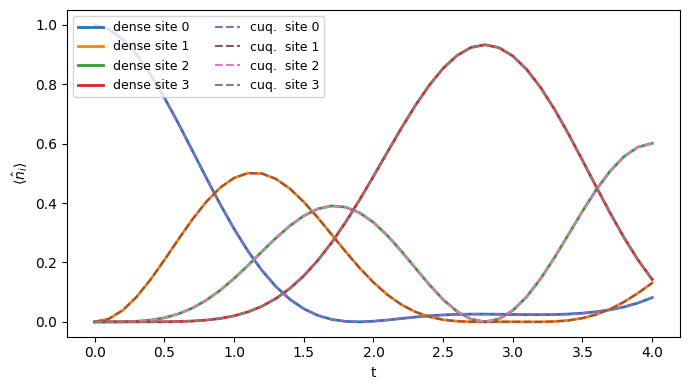

In [11]:
# Per-site occupation <n_i>(t) for both backends.
import matplotlib.pyplot as plt

def site_n_op(site, impl, n_sites=n_sites, d=d):
    a_local = jqt.destroy(d, implementation=impl)
    I_local = jqt.identity(d, implementation=impl)
    ops = [I_local] * n_sites
    ops[site] = a_local.dag() @ a_local
    return jqt.tensor(*ops)

ns_dense = [site_n_op(i, "dense") for i in range(n_sites)]

# <O>(t) = Tr(O rho)
def expect(op, rho_t):
    op_d = op.to_dense().data
    rho_d = rho_t.to_dense().data
    return jnp.real(jnp.einsum('ij,tji->t', op_d, rho_d))

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(n_sites):
    ax.plot(tlist, expect(ns_dense[i], ref), label=f"dense site {i}", lw=2)
if HAS_CUDA and cu is not None:
    ns_cu = [site_n_op(i, "cuquantum") for i in range(n_sites)]
    for i in range(n_sites):
        ax.plot(tlist, expect(ns_cu[i], cu), "--", label=f"cuq.  site {i}", lw=1.5)
ax.set_xlabel("t")
ax.set_ylabel(r"$\langle\hat{n}_i\rangle$")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

In [12]:
# Numerical parity check.
if HAS_CUDA and cu is not None:
    match = jnp.allclose(ref.data, cu.data, atol=1e-5)
    max_err = float(jnp.max(jnp.abs(ref.data - cu.data)))
    print(f"Trajectories match (atol=1e-5): {bool(match)}")
    print(f"Max abs error:                  {max_err:.2e}")
else:
    print("Parity check skipped: cuquantum mesolve requires CUDA.")

Trajectories match (atol=1e-5): True
Max abs error:                  6.11e-16


## 8. Timing comparison

Now the headline reason to use cuquantum: speed at scale.

`mesolve` is JIT-compiled by JAX, so the first call pays a one-time compilation cost. We warm up both backends with a single short run, then time the *steady-state* per-step cost. Increasing `n_sites` quickly makes the dense backend infeasible while cuquantum keeps going — its memory and per-step cost scale with the **per-mode** dimensions, not with the full Kronecker product.

In [22]:
import time

def time_mesolve(H, rho0, tlist, c_ops, *, n_runs=1, label=""):
    """Run ``mesolve`` once to warm JIT, then time ``n_runs`` more calls.

    Returns the median wall time per run (excluding compilation).
    """


    opts = jqt.SolverOptions.create(progress_meter=False, solver="Euler", stepsize_controller="ConstantStepSize")
    # Warm up: pay JIT cost once.
    out = jqt.mesolve(H, rho0, tlist, c_ops=c_ops, solver_options=opts)
    out.data.block_until_ready()  # block on the device to make timing honest

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        out = jqt.mesolve(H, rho0, tlist, c_ops=c_ops, solver_options=opts)
        out.data.block_until_ready()
        times.append(time.perf_counter() - t0)
    median = sorted(times)[len(times) // 2]
    print(f"{label:>12s}  median: {median:7.3f} s   (runs: {[f'{t:.3f}' for t in times]})")
    return median

print(f"timing mesolve at n_sites={n_sites}, d={d}, hilbert dim={d**n_sites}")
t_dense = time_mesolve(H_dense, rho0, tlist,
                       c_ops=jqt.Qarray.from_list([L0_dense]),
                       label="dense")
if HAS_CUDA:
    t_cu = time_mesolve(H_cu, rho0, tlist,
                        c_ops=[L0_cu],
                        label="cuquantum")
    print(f"\nspeedup (dense / cuquantum): {t_dense / t_cu:.2f}x")
else:
    t_cu = float("nan")
    print("cuquantum timing skipped: no CUDA device.")

timing mesolve at n_sites=4, d=3, hilbert dim=81
       dense  median:   1.111 s   (runs: ['1.111'])
   cuquantum  median:   1.246 s   (runs: ['1.246'])

speedup (dense / cuquantum): 0.89x


### 8.1 Scaling sweep

Sweep `n_sites` and watch the dense wall time blow up as $d^{n_\text{sites}}$. The cuquantum line should stay nearly flat over this range — its cost is dominated by the per-mode `OperatorTerm` algebra and the GPU matvec, not the full state-vector size.

The sweep stops the dense backend at a `dense_max_dim` cap so the notebook still runs on a modest box. cuquantum continues past it.

In [14]:
sweep_sites = [3, 4, 5, 6]      # extend to 7, 8, 9 ... on a real GPU
dense_max_dim = 800              # skip dense once Hilbert dim exceeds this

results = {"n_sites": [], "dim": [], "dense": [], "cuquantum": []}

for n in sweep_sites:
    H_d, L_d = bose_hubbard_chain("dense", n_sites=n)
    psi0_n = jqt.basis_like(H_d, [1] + [0] * (n - 1))
    rho0_n = psi0_n.to_dm()
    dim = d ** n

    print(f"\n--- n_sites={n}, dim={dim} ---")

    if dim <= dense_max_dim:
        t_d = time_mesolve(H_d, rho0_n, tlist,
                           c_ops=jqt.Qarray.from_list([L_d]),
                           label="dense")
    else:
        t_d = float("nan")
        print(f"{'dense':>12s}  skipped (dim > dense_max_dim={dense_max_dim})")

    if HAS_CUDA:
        H_c, L_c = bose_hubbard_chain("cuquantum", n_sites=n)
        t_c = time_mesolve(H_c, rho0_n, tlist,
                           c_ops=[L_c],
                           label="cuquantum")
    else:
        t_c = float("nan")

    results["n_sites"].append(n)
    results["dim"].append(dim)
    results["dense"].append(t_d)
    results["cuquantum"].append(t_c)

if not HAS_CUDA:
    print("\nNote: cuquantum timings skipped (no CUDA). Run on a GPU box for the full comparison.")


--- n_sites=3, dim=27 ---
       dense  median:   1.068 s   (runs: ['1.068'])
   cuquantum  median:   1.363 s   (runs: ['1.363'])

--- n_sites=4, dim=81 ---
       dense  median:   1.032 s   (runs: ['1.032'])
   cuquantum  median:   1.279 s   (runs: ['1.279'])

--- n_sites=5, dim=243 ---
       dense  median:   1.086 s   (runs: ['1.086'])
   cuquantum  median:   1.621 s   (runs: ['1.621'])

--- n_sites=6, dim=729 ---
       dense  median:   1.891 s   (runs: ['1.891'])
   cuquantum  median:   2.689 s   (runs: ['2.689'])


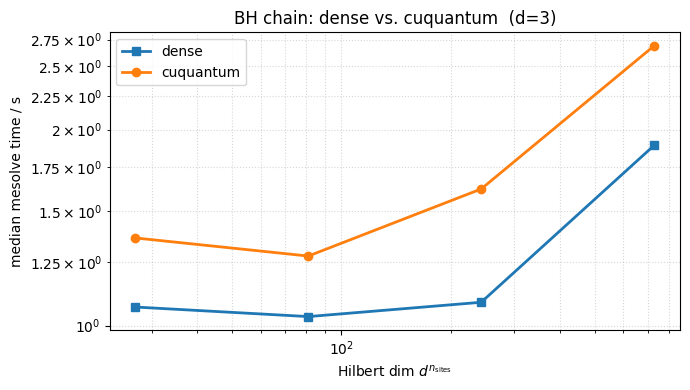

In [15]:
import math

fig, ax = plt.subplots(figsize=(7, 4))
dims = results["dim"]

dense_pts = [(x, y) for x, y in zip(dims, results["dense"]) if not math.isnan(y)]
if dense_pts:
    xs, ys = zip(*dense_pts)
    ax.plot(xs, ys, "s-", label="dense", lw=2)

cu_pts = [(x, y) for x, y in zip(dims, results["cuquantum"]) if not math.isnan(y)]
if cu_pts:
    xs, ys = zip(*cu_pts)
    ax.plot(xs, ys, "o-", label="cuquantum", lw=2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Hilbert dim $d^{n_\mathrm{sites}}$")
ax.set_ylabel("median mesolve time / s")
ax.set_title(f"BH chain: dense vs. cuquantum  (d={d})")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()

## Where to go next

- See [`local/lattice_2d_operator_action.py`](https://github.com/EQuS/jaxquantum/blob/main/local/lattice_2d_operator_action.py) for a 2D qudit lattice that compares dense and cuquantum mesolve at scale.
- The cuquantum backend currently does **not** support batched Qarrays, the propagator's static-H `expm` branch, or sparse-data fallbacks. For those use the `"dense"`, `"sparse_bcoo"`, or `"sparse_dia"` backends.
- The construction / arithmetic paths are exercised in `test/test_cuquantum_backend.py` and don't need a GPU. The GPU-bound solver tests are tagged with the `cuquantum` pytest marker; CI's default invocation excludes them via `-m "not cuquantum"`.